# Level 2 · Task 3 — K-Means Clustering (Customer Segmentation)
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Segment telecom customers into groups using **unsupervised** K-Means.
**Steps:** load & scale → find optimal K (elbow + silhouette) → cluster → visualize in 2D (PCA)
→ interpret segments.
**Dataset:** `churn_train.csv` (numeric usage features; the churn label is not used).
**Tools:** Python, scikit-learn, matplotlib, seaborn.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
sns.set_style("whitegrid")
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load & Prepare
Clustering is unsupervised, so we drop the label (`Churn`) and keep only the numeric
behavioural features (minutes, calls, charges, service calls, etc.).

In [2]:
df = pd.read_csv("../../data/churn_train.csv")
X = df.select_dtypes(include="number").copy()   # numeric features only
print("Customers:", X.shape[0], "| Features:", X.shape[1])
X.head()

Customers: 2666 | Features: 16


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


## Step 2 — Scale the Features
K-Means uses Euclidean distance, so features must be on the same scale.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (2666, 16)


## Step 3 — Find the Optimal Number of Clusters
- **Elbow method:** plot inertia (within-cluster spread) vs K; the "elbow" is a good K.
- **Silhouette score:** higher = better-separated clusters.

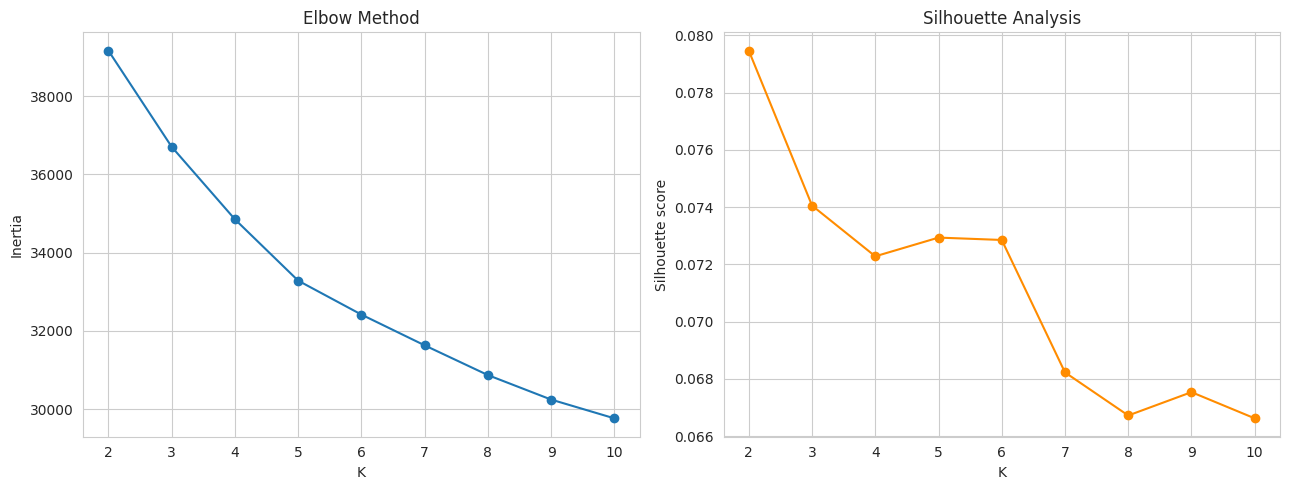

Best K by silhouette: 2


In [4]:
K_range = range(2, 11)
inertia, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].plot(list(K_range), inertia, marker="o")
ax[0].set_xlabel("K"); ax[0].set_ylabel("Inertia"); ax[0].set_title("Elbow Method")
ax[1].plot(list(K_range), silhouettes, marker="o", color="darkorange")
ax[1].set_xlabel("K"); ax[1].set_ylabel("Silhouette score"); ax[1].set_title("Silhouette Analysis")
plt.tight_layout()
plt.savefig("output_elbow_silhouette.png", dpi=110)
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print("Best K by silhouette:", best_k)

## Step 4 — Fit Final K-Means & Visualize with PCA
We reduce the many features to 2 dimensions (PCA) purely for plotting, and colour points
by their assigned cluster.

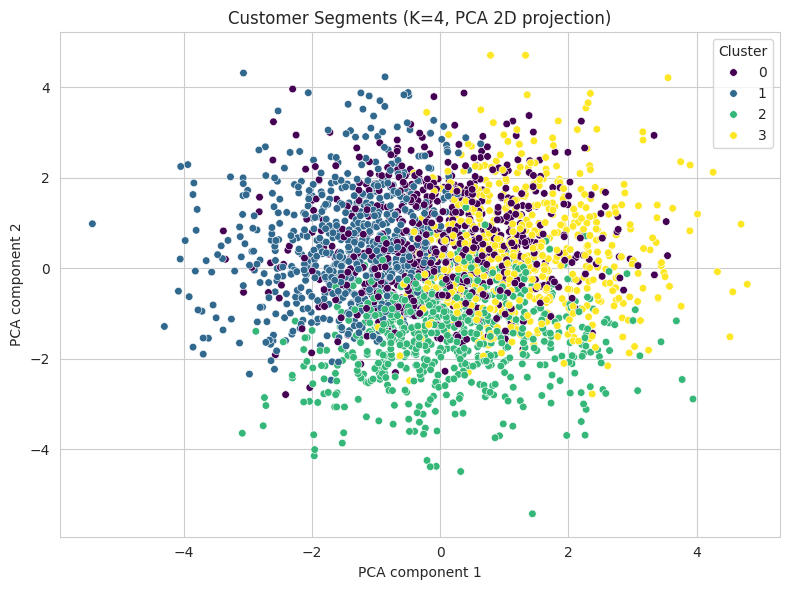

PCA explains 25.5% of variance in 2D


In [5]:
k = 4   # chosen from elbow/silhouette (adjust if your run suggests otherwise)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=clusters, palette="viridis", s=30)
plt.xlabel("PCA component 1"); plt.ylabel("PCA component 2")
plt.title(f"Customer Segments (K={k}, PCA 2D projection)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("output_clusters.png", dpi=110)
plt.show()
print(f"PCA explains {pca.explained_variance_ratio_.sum():.1%} of variance in 2D")

## Step 5 — Interpret the Segments
We attach the cluster label back to the original data and inspect the average profile of each
segment on a few business-relevant features.

In [6]:
profile_cols = ["Account length", "Total day minutes", "Total day charge",
                "Customer service calls", "Number vmail messages"]
seg = X.copy()
seg["Cluster"] = clusters
summary = seg.groupby("Cluster")[profile_cols].mean().round(1)
summary["Size"] = seg["Cluster"].value_counts().sort_index()
summary

,Account length,Total day minutes,Total day charge,Customer service calls,Number vmail messages,Size
Cluster,,,,,,
0,102.1,229.3,39.0,1.5,9.0,694
1,101.6,124.4,21.1,1.6,6.7,667
2,99.3,174.7,29.7,1.6,7.8,686
3,99.3,188.4,32.0,1.6,8.6,619


**Reading it:** each row is a customer segment. Comparing the averages reveals, for example,
high-usage vs low-usage customers, or a group with many customer-service calls (an at-risk
segment worth targeting with retention offers).

## Summary
| Item | Result |
|------|--------|
| Method | K-Means (unsupervised) |
| K selection | Elbow + silhouette |
| Visualization | PCA 2D scatter |
| Output | Interpretable customer segments |

K-Means groups customers into distinct behavioural segments, useful for targeted marketing
and retention. ✅ **Level 2 · Task 3 complete.**